# Minneapolis LVT Shift — Full-Bill Split-Rate (4:1)

Revenue-neutral shift to a **split-rate property tax** (land taxed at 4× the improvement rate)
for the **City of Minneapolis**, Hennepin County, Minnesota. Mirrors the St. Paul model.

| Decision | Choice |
|---|---|
| **Levy scope** | **Full stack** — city + Hennepin County + school + special districts. `current_tax` = observed `TOT_NET_TAX` (value-based net tax, all jurisdictions; excludes special assessments). |
| **Reform** | Split-rate **4:1** on **Net Tax Capacity** components (preserves MN class-rate preferences). |
| **Exemptions** | Preserve all — fully-exempt and TIF parcels keep current treatment; revenue neutrality holds on the taxable base. |

**Minnesota Tax Capacity**: the state defines Net Tax Capacity (NTC) via class-rate schedules
(pre-computed as `NET_TC*`). The split-rate operates on NTC components, not raw market value, so
class-rate progressivity is preserved.

**Condo treatment — NO collapse** (differs from St. Paul / Ramsey). Hennepin apportions *real*
land values to condo units (condo land ≈ $714M across 25,040 units; only ~12% have land ≤
$1,000), versus Ramsey's $1,000 tokens. Unit-level data is internally consistent and there is no
clean building-plat ID, so condos are modeled as-is.

**Data source**: Hennepin County GIS, `HennepinData/LAND_PROPERTY/MapServer/1` (County Parcels).
Neighborhood geographies: City of Minneapolis Communities (11) and Neighborhoods (87).

In [1]:
# Step 1: Load parcel data
import sys, os, json
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from dotenv import load_dotenv

sys.path.insert(0, '../..')
REPO_ROOT = Path('../..').resolve()
load_dotenv(REPO_ROOT / '.env')

from lvt.lvt_utils import (
    model_split_rate_tax, calculate_category_tax_summary, print_category_tax_summary,
    save_standard_export,
)
from lvt.policy_analysis import analyze_vacant_land, analyze_land_by_improvement_share
from lvt.census_utils import get_census_data_with_boundaries, match_to_census_blockgroups
pd.set_option('display.max_columns', None)

CITY_NAME = 'minneapolis'
STATE_FIPS = '27'
COUNTY_FIPS = '053'
MODEL_TYPE = 'split_rate:4.0'
tc_land_improvement_ratio = 4

DATA_DIR = Path('data'); DATA_DIR.mkdir(exist_ok=True)
PARCEL_PATH = DATA_DIR / 'parcels.gpq'

HENNEPIN_URL = ('https://gis.hennepin.us/arcgis/rest/services/'
                'HennepinData/LAND_PROPERTY/MapServer/1/query')
_seg = lambda b: [f'{b}{i}' for i in (1, 2, 3, 4)]
OUTFIELDS = (['PID', 'MUNIC_NM', 'PR_TYP_NM1', 'STATE_CD', 'HMSTD_CD1', 'CONDO_NO',
              'TIF_PROJECT_NO', 'SCHOOL_DIST_NO', 'MKT_VAL_TOT', 'TAXABLE_VAL_TOT',
              'TOT_NET_TAX', 'TOT_SPEC_TAX', 'TAX_TOT']
             + _seg('LAND_MV') + _seg('BLDG_MV') + _seg('NET_TC'))

def fetch_hennepin(where="MUNIC_NM='MINNEAPOLIS'", outfields=OUTFIELDS):
    n = requests.get(HENNEPIN_URL, params={'where': where, 'returnCountOnly': 'true',
                                           'f': 'json'}).json()['count']
    print(f"Server reports {n:,} parcels for: {where}")
    feats, offset = [], 0
    while offset < n:
        d = requests.get(HENNEPIN_URL, params={
            'where': where, 'outFields': ','.join(outfields), 'returnGeometry': 'true',
            'outSR': 3857, 'resultOffset': offset, 'resultRecordCount': 2000,
            'f': 'geojson'}).json()
        fs = d.get('features', [])
        if not fs:
            break
        feats.extend(fs); offset += len(fs)
        print(f"  fetched {offset:,}/{n:,}")
    return gpd.GeoDataFrame.from_features(feats, crs='EPSG:3857')

if PARCEL_PATH.exists():
    minneapolis_gdf = gpd.read_parquet(PARCEL_PATH)
    print(f"Loaded {len(minneapolis_gdf):,} parcels from cache")
else:
    minneapolis_gdf = fetch_hennepin()
    minneapolis_gdf.to_parquet(PARCEL_PATH)
    print(f"Downloaded and cached {len(minneapolis_gdf):,} Minneapolis parcels")

# Aggregate split-class segments (*1..*4) to parcel totals
for base, out in [('LAND_MV', 'land_mv'), ('BLDG_MV', 'bldg_mv'), ('NET_TC', 'net_tc')]:
    minneapolis_gdf[out] = minneapolis_gdf[[f'{base}{i}' for i in (1, 2, 3, 4)]].fillna(0).sum(axis=1)
minneapolis_gdf['emv_total'] = minneapolis_gdf['land_mv'] + minneapolis_gdf['bldg_mv']
minneapolis_gdf['current_tax'] = pd.to_numeric(minneapolis_gdf['TOT_NET_TAX'],
                                               errors='coerce').fillna(0.0)

Loaded 128,750 parcels from cache


## Step 2: Validate Against Official Tax Base

Full-stack `current_tax` is the observed `TOT_NET_TAX` — the actual billed net property tax
across all jurisdictions, extracted from the county tax system, so it is authoritative by
construction. As an external anchor we compare the city-controlled levy (City + Pensions +
Park Board + MBC) against the full-bill total: a ~35–40% city share is typical in Minnesota.

In [2]:
# Official anchor: 2024 City of Minneapolis adopted levy (City + Pensions + Park Board + MBC)
# Source: City of Minneapolis 2024 Adopted Budget (levy = $472.1M, +6.2% over 2023's $444.4M).
CITY_LEVY_2024 = 472_100_000
official_data = {
    'City-controlled levy (2024 adopted)': CITY_LEVY_2024,
}
full_bill_all = minneapolis_gdf['current_tax'].sum()
print('OFFICIAL ANCHOR')
for k, v in official_data.items():
    print(f'  {k}: ${v:,.0f}')
print(f"\nObserved full-bill net tax (all Mpls parcels): ${full_bill_all:,.0f}")
print(f"City levy as share of full bill: {CITY_LEVY_2024/full_bill_all*100:.1f}%  "
      f"(typical MN city share is ~35-40%)")

OFFICIAL ANCHOR
  City-controlled levy (2024 adopted): $472,100,000

Observed full-bill net tax (all Mpls parcels): $1,206,085,984
City levy as share of full bill: 39.1%  (typical MN city share is ~35-40%)


## Step 3: Flag TIF and Exempt Parcels

The county feature service is already filtered to Minneapolis server-side (`MUNIC_NM`). Here we
flag TIF and fully-exempt parcels and build the city-taxable working set. TIF and fully-exempt
parcels are excluded from the revenue-neutral reform base (their tax is unchanged).

In [3]:
# Flag TIF, exempt, condo; build taxable mask
minneapolis_gdf['in_tif'] = (
    minneapolis_gdf['TIF_PROJECT_NO'].notna()
    & (minneapolis_gdf['TIF_PROJECT_NO'].astype(str).str.strip() != '')
)
minneapolis_gdf['is_condo'] = (
    minneapolis_gdf['CONDO_NO'].notna()
    & (minneapolis_gdf['CONDO_NO'].astype(str).str.strip() != '')
)
minneapolis_gdf['fully_exempt'] = (
    (minneapolis_gdf['current_tax'] <= 0) | (minneapolis_gdf['net_tc'] <= 0)
)
minneapolis_gdf['pays_city_tax'] = (
    ~minneapolis_gdf['in_tif'] & ~minneapolis_gdf['fully_exempt']
    & (minneapolis_gdf['net_tc'] > 0)
)
print(f'Total Minneapolis parcels: {len(minneapolis_gdf):,}')
print(f"  In TIF districts:   {minneapolis_gdf['in_tif'].sum():,}")
print(f"  Fully tax exempt:   {minneapolis_gdf['fully_exempt'].sum():,}")
print(f"  Condo units:        {minneapolis_gdf['is_condo'].sum():,}")
print(f"  City-taxable:       {minneapolis_gdf['pays_city_tax'].sum():,}")

Total Minneapolis parcels: 128,750
  In TIF districts:   1,387
  Fully tax exempt:   4,713
  Condo units:        25,040
  City-taxable:       122,736


In [4]:
# Validate scraped tax base against the official anchor
scraped_total_ntc = minneapolis_gdf['net_tc'].sum()
scraped_tif_ntc = minneapolis_gdf[minneapolis_gdf['in_tif']]['net_tc'].sum()
scraped_city_taxable_ntc = minneapolis_gdf[minneapolis_gdf['pays_city_tax']]['net_tc'].sum()
scraped_total_emv = minneapolis_gdf['emv_total'].sum()

print('SCRAPED TAX BASE (Minneapolis)')
print(f"{'Total Net Tax Capacity':<30} ${scraped_total_ntc:>15,.0f}")
print(f"{'TIF Net Tax Capacity':<30} ${scraped_tif_ntc:>15,.0f}")
print(f"{'City-Taxable NTC':<30} ${scraped_city_taxable_ntc:>15,.0f}")
print(f"{'Total Market Value':<30} ${scraped_total_emv:>15,.0f}")
print(f"{'Observed full-bill net tax':<30} ${minneapolis_gdf['current_tax'].sum():>15,.0f}")
print(f"\nSegment land+bldg vs MKT_VAL_TOT — median abs diff: "
      f"${(minneapolis_gdf['emv_total']-minneapolis_gdf['MKT_VAL_TOT']).abs().median():,.0f}")

SCRAPED TAX BASE (Minneapolis)
Total Net Tax Capacity         $    760,599,070
TIF Net Tax Capacity           $     20,200,223
City-Taxable NTC               $    740,398,847
Total Market Value             $ 64,406,993,800
Observed full-bill net tax     $  1,206,085,984

Segment land+bldg vs MKT_VAL_TOT — median abs diff: $0


In [5]:
# Create working dataset: city-taxable parcels with FULL tax bill
mpls = minneapolis_gdf[minneapolis_gdf['pays_city_tax']].copy()

# FULL BILL: current_tax = TOT_NET_TAX (all jurisdictions) — already set
current_revenue = mpls['current_tax'].sum()
implied_full_rate = current_revenue / mpls['net_tc'].sum()

print('FULL-BILL TAX BASE')
print(f'Parcels:            {len(mpls):,}')
print(f'Net Tax Capacity:   ${mpls["net_tc"].sum():,.0f}')
print(f'Total Tax Revenue:  ${current_revenue:,.0f}')
print(f'Implied full rate:  {implied_full_rate:.4f}')
print(f'\nCompare to city-controlled levy: ${CITY_LEVY_2024:,.0f} '
      f'({CITY_LEVY_2024/full_bill_all*100:.1f}% of full bill)')

FULL-BILL TAX BASE
Parcels:            122,736
Net Tax Capacity:   $740,398,847
Total Tax Revenue:  $1,173,957,566
Implied full rate:  1.5856

Compare to city-controlled levy: $472,100,000 (39.1% of full bill)


## Step 3b: Condo Treatment (No Collapse)

Ramsey County (St. Paul) assigns condo units **token** $1,000 land values, forcing a condo
collapse + land imputation. **Hennepin apportions real land values to condo units**, so no
collapse is performed here. The cell below confirms the condo land base is substantive (not a
token), which is the data-integrity justification for modeling condos as-is.

In [6]:
# Condo data-integrity check — confirms apportioned (not token) land values
_cond = minneapolis_gdf[minneapolis_gdf['is_condo']]
_n_token = (_cond['land_mv'] <= 1000).sum()
print(f'Condo units: {len(_cond):,}')
print(f'  Condo land MV sum:  ${_cond["land_mv"].sum():,.0f}')
print(f'  Condo bldg MV sum:  ${_cond["bldg_mv"].sum():,.0f}')
print(f'  Condo aggregate IR: {_cond["bldg_mv"].sum()/(_cond["land_mv"].sum()+_cond["bldg_mv"].sum())*100:.1f}%')
print(f'  Units with land <= $1,000: {_n_token:,} ({_n_token/len(_cond)*100:.1f}%)')
print('\nLand base is substantive and apportioned -> condos modeled as-is (no collapse).')

Condo units: 25,040
  Condo land MV sum:  $713,598,400
  Condo bldg MV sum:  $5,189,508,400
  Condo aggregate IR: 87.9%
  Units with land <= $1,000: 2,980 (11.9%)

Land base is substantive and apportioned -> condos modeled as-is (no collapse).


## Step 4: Categorize Properties

In [7]:
def categorize_minneapolis(row):
    nm = str(row.get('PR_TYP_NM1', '') or '').upper().strip()
    if 'VACANT LAND' in nm or nm.startswith('LAND'):
        return 'Vacant Land'
    if nm in ('RESIDENTIAL', 'RESIDENTIAL-ZERO LOT LINE'):
        return 'Single Family Residential'
    if nm == 'TOWNHOUSE':
        return 'Townhome / Rowhouse'
    if nm in ('RESIDENTIAL-TWO UNIT', 'TRIPLEX'):
        return 'Small Multi-Family (2-4 units)'
    if nm in ('APARTMENT', 'LOW INCOME RENTAL', 'COOPERATIVE HOUSING',
              'AG NHSTD MULT UNIT', 'MED/CARE FACILITY'):
        return 'Large Multi-Family (5+ units)'
    if nm in ('CONDOMINIUM', 'CONDO GARAGE/MISCELLANEOUS'):
        return 'Condominium'
    if nm.startswith('COMMERCIAL'):
        return 'Commercial'
    if nm.startswith('INDUSTRIAL'):
        return 'Industrial'
    return 'Other'

mpls['PROPERTY_CATEGORY'] = mpls.apply(categorize_minneapolis, axis=1)
# Override: $0 improvement -> Vacant Land
mpls.loc[mpls['bldg_mv'] <= 0, 'PROPERTY_CATEGORY'] = 'Vacant Land'

print('Property Category Distribution:')
print(mpls['PROPERTY_CATEGORY'].value_counts())

Property Category Distribution:
PROPERTY_CATEGORY
Single Family Residential         74429
Condominium                       24085
Small Multi-Family (2-4 units)    10939
Large Multi-Family (5+ units)      5705
Commercial                         3321
Vacant Land                        2435
Townhome / Rowhouse                 833
Industrial                          530
Other                               459
Name: count, dtype: int64


## Step 5: Calculate IR, Split Net Tax Capacity, Run Model

In [8]:
# Calculate Improvement Ratio and split Net Tax Capacity
mpls['IR'] = (mpls['bldg_mv'] / mpls['emv_total']).fillna(0).clip(0, 1)
mpls['NetTC_Improvements'] = mpls['IR'] * mpls['net_tc']
mpls['NetTC_Land'] = (1 - mpls['IR']) * mpls['net_tc']

print('Net Tax Capacity Split Summary:')
print(f'  Total Net Tax Capacity:      ${mpls["net_tc"].sum():>15,.0f}')
print(f'  NTC (Improvements):          ${mpls["NetTC_Improvements"].sum():>15,.0f}')
print(f'  NTC (Land):                  ${mpls["NetTC_Land"].sum():>15,.0f}')
print(f'  Land % of NTC:               {mpls["NetTC_Land"].sum()/mpls["net_tc"].sum()*100:.1f}%')

# Run split-rate model at 4:1 ratio on FULL tax bill
tc_land_millage, tc_imp_millage, tc_split_rate_revenue, mpls = model_split_rate_tax(
    df=mpls,
    land_value_col='NetTC_Land',
    improvement_value_col='NetTC_Improvements',
    current_revenue=current_revenue,
    land_improvement_ratio=tc_land_improvement_ratio,
)

mpls['new_tax_tc'] = mpls['new_tax']
mpls['tax_change_tc'] = mpls['new_tax_tc'] - mpls['current_tax']
mpls['tax_change_pct_tc'] = np.where(
    mpls['current_tax'] > 0, (mpls['tax_change_tc'] / mpls['current_tax']) * 100, 0
)

print(f'\nFull-Bill Split-Rate Model ({tc_land_improvement_ratio}:1 ratio)')
print(f'  Land Millage:        {tc_land_millage:.6f}')
print(f'  Improvement Millage: {tc_imp_millage:.6f}')
print(f'  Current Revenue:     ${current_revenue:,.0f}')
print(f'  New Revenue:         ${mpls["new_tax_tc"].sum():,.0f}')
print(f'  Revenue neutral:     {abs(current_revenue - mpls["new_tax_tc"].sum()) < 1}')

# Undeveloped and underdeveloped land analysis
vacant_results = analyze_vacant_land(
    mpls, land_value_col='land_mv', property_type_col='PROPERTY_CATEGORY',
    vacant_identifier='Vacant Land', improvement_value_col='bldg_mv')
underdeveloped_results = analyze_land_by_improvement_share(
    mpls, land_value_col='land_mv', improvement_value_col='bldg_mv')

total_land_emv = mpls['land_mv'].sum()
print(f'\nUndeveloped and Underdeveloped Land')
print(f'  Total non-exempt land MV: ${total_land_emv:,.0f}')
print(f'\n  Undeveloped (vacant, IR=0):')
print(f'    {vacant_results["total_vacant_parcels"]:,} parcels')
print(f'    ${vacant_results["total_vacant_land_value"]:,.0f} ({vacant_results["vacant_land_pct_of_total"]:.1f}% of non-exempt land value)')
print(f'\n  Underdeveloped (by improvement share):')
for cat in underdeveloped_results['categories']:
    print(f'    {cat["category"]:35s} {cat["parcel_count"]:>6,} parcels  ${cat["adjusted_land_value"]:>15,.0f}  ({cat["share_of_total_land_value_pct"]:.1f}%)')

Net Tax Capacity Split Summary:
  Total Net Tax Capacity:      $    740,398,847
  NTC (Improvements):          $    523,754,955
  NTC (Land):                  $    216,643,892
  Land % of NTC:               29.3%

Full-Bill Split-Rate Model (4:1 ratio)
  Land Millage:        3377.492034
  Improvement Millage: 844.373008
  Current Revenue:     $1,173,957,566
  New Revenue:         $1,173,957,566
  Revenue neutral:     True

Undeveloped and Underdeveloped Land
  Total non-exempt land MV: $18,131,615,200

  Undeveloped (vacant, IR=0):
    2,435 parcels
    $536,004,500 (3.0% of non-exempt land value)

  Underdeveloped (by improvement share):
    0% improvement                       2,435 parcels  $    536,004,500  (3.0%)
    <10% improvement (excl. 0%)            348 parcels  $    446,544,100  (2.5%)
    10-25% improvement                     626 parcels  $    361,258,100  (2.0%)
    25-50% improvement                  12,124 parcels  $  3,364,528,300  (18.6%)
    >0%-25% improvement     

## Step 6: Category Summary & Charts

In [9]:
# Tax impact summary by property category
mpls['abs_tax_diff'] = (mpls['current_tax'] - mpls['new_tax_tc']).abs()
total_abs_tax_diff = mpls['abs_tax_diff'].sum()
percent_of_current = (total_abs_tax_diff / current_revenue) * 100
print(f'Sum of absolute tax difference: ${total_abs_tax_diff:,.2f}')
print(f'That is {percent_of_current:.2f}% of current full tax revenue.\n')

output_summary = calculate_category_tax_summary(
    mpls, category_col='PROPERTY_CATEGORY', current_tax_col='current_tax',
    new_tax_col='new_tax_tc')
print_category_tax_summary(output_summary, 'Full-Bill Split-Rate Impact by Property Category')

Sum of absolute tax difference: $313,095,765.39
That is 26.67% of current full tax revenue.


Full-Bill Split-Rate Impact by Property Category
                      Category  Count Total Tax Δ ($) Total Δ (%) Mean Δ ($) Median Δ ($) Avg % Δ Median % Δ % Parcels > +10% % Parcels < -10%
     Single Family Residential  74429     $75,426,392       16.5%     $1,013         $851   13.2%      16.1%            61.2%            19.9%
                   Condominium  24085    $-21,013,318      -25.4%      $-872        $-379  -21.8%     -28.3%             8.5%            80.0%
Small Multi-Family (2-4 units)  10939      $3,356,409        4.1%       $307         $249    1.9%       3.7%            34.9%            26.0%
 Large Multi-Family (5+ units)   5705    $-51,671,806      -24.0%    $-9,057        $-718  -15.0%     -20.4%            11.6%            68.2%
                    Commercial   3321    $-26,145,764      -10.8%    $-7,873      $-1,113   -1.8%     -11.8%            26.7%            52.1%

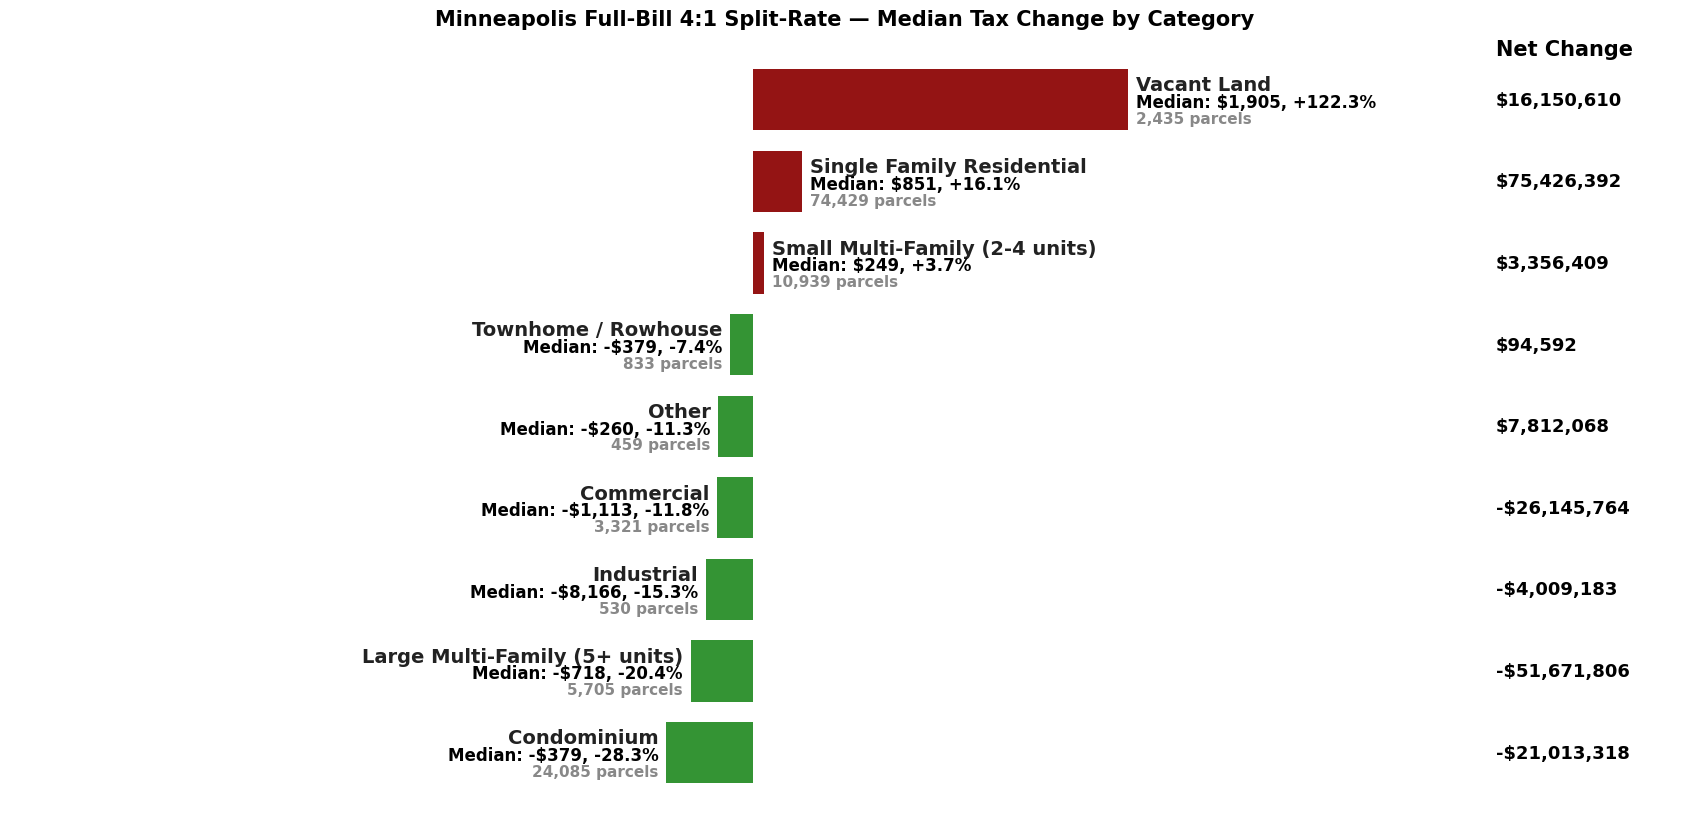

In [10]:
# Horizontal bar chart: median % change by category
filtered = output_summary[output_summary['property_count'] > 50].copy()

categories = filtered['PROPERTY_CATEGORY'].tolist()
counts = filtered['property_count'].tolist()
median_pct_change = filtered['median_tax_change_pct'].tolist()
median_dollar_change = filtered['median_tax_change'].tolist()
total_tax_change = filtered['total_tax_change'].tolist() if 'total_tax_change' in filtered.columns else (filtered['mean_tax_change'] * filtered['property_count']).tolist()

sorted_idx = np.argsort(median_pct_change)
categories = [categories[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
median_pct_change = [median_pct_change[i] for i in sorted_idx]
median_dollar_change = [median_dollar_change[i] for i in sorted_idx]
total_tax_change = [total_tax_change[i] for i in sorted_idx]

bar_colors = ['#8B0000' if val > 0 else '#228B22' for val in median_pct_change]
bar_height = 0.75
fig_height = len(categories) * 0.8 + 1.2
right_col_pad = 120
fig, ax = plt.subplots(figsize=(17, fig_height))
y = np.arange(len(categories))
ax.barh(y, median_pct_change, color=bar_colors, edgecolor='none', height=bar_height, alpha=0.92, linewidth=0, zorder=2)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
cat_offset, med_offset, count_offset = 0.18, -0.03, -0.23
max_abs = max(abs(min(median_pct_change)), abs(max(median_pct_change)))
right_col_x = max_abs + right_col_pad
ax.text(right_col_x, len(categories) - 0.5, 'Net Change', va='bottom', ha='left', fontsize=15, fontweight='bold', color='black')
for i, (cat, val, count, med_dol, tot_change) in enumerate(zip(categories, median_pct_change, counts, median_dollar_change, total_tax_change)):
    med_dol_str = f'${med_dol:,.0f}' if med_dol >= 0 else f'-${abs(med_dol):,.0f}'
    median_combo = f'Median: {med_dol_str}, {val:+.1f}%'
    xpos = val - 2.5 if val < 0 else val + 2.5
    ha = 'right' if val < 0 else 'left'
    ax.text(xpos, y[i]+cat_offset, cat, va='center', ha=ha, fontsize=14, fontweight='bold', color='#222')
    ax.text(xpos, y[i]+med_offset, median_combo, va='center', ha=ha, fontsize=12, fontweight='bold', color='black')
    ax.text(xpos, y[i]+count_offset, f'{count:,} parcels', va='center', ha=ha, fontsize=11, fontweight='bold', color='#888')
    tot_change_str = f'${tot_change:,.0f}' if tot_change >= 0 else f'-${abs(tot_change):,.0f}'
    ax.text(right_col_x, y[i], tot_change_str, va='center', ha='left', fontsize=13, fontweight='bold', color='black')
ax.set_xlim(-right_col_x, right_col_x + 60)
ax.set_yticks([]); ax.set_xticks([])
ax.set_title(f'Minneapolis Full-Bill {tc_land_improvement_ratio}:1 Split-Rate — Median Tax Change by Category', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

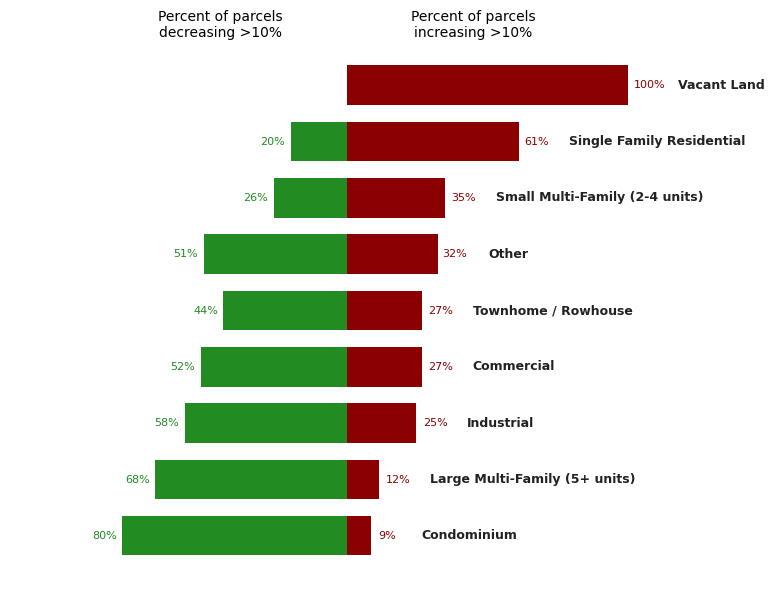

In [11]:
# Butterfly chart: percent of parcels increasing/decreasing >10%
summary_filtered = output_summary[output_summary['property_count'] > 50].copy()
summary_sorted = summary_filtered.sort_values('pct_increase_gt_threshold', ascending=True)
categories_sorted = summary_sorted['PROPERTY_CATEGORY'].tolist()
pct_increase_sorted = summary_sorted['pct_increase_gt_threshold'].tolist()
pct_decrease_sorted = summary_sorted['pct_decrease_gt_threshold'].tolist()
pct_increase_int = [int(round(x)) for x in pct_increase_sorted]
pct_decrease_int = [int(round(x)) for x in pct_decrease_sorted]
y = np.arange(len(categories_sorted))
fig, ax = plt.subplots(figsize=(8, 6))
color_increase, color_decrease = '#8B0000', '#228B22'
ax.barh(y, [-v for v in pct_decrease_sorted], color=color_decrease, edgecolor='none', height=0.7)
ax.barh(y, pct_increase_sorted, color=color_increase, edgecolor='none', height=0.7)
for i, (inc, dec) in enumerate(zip(pct_increase_int, pct_decrease_int)):
    if dec > 0:
        ax.text(-dec - 2, y[i], f'{dec}%', va='center', ha='right', fontsize=8, color=color_decrease)
    if inc > 0:
        ax.text(inc + 2, y[i], f'{inc}%', va='center', ha='left', fontsize=8, color=color_increase)
for i, (cat, inc) in enumerate(zip(categories_sorted, pct_increase_sorted)):
    xpos = inc + 18 if inc > 0 else 18
    ax.text(xpos, y[i], cat, va='center', ha='left', fontsize=9, fontweight='bold', color='#222')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.set_yticks([]); ax.set_xticks([])
max_val = max(max(pct_increase_sorted), max(pct_decrease_sorted))
ax.set_xlim(-max_val-20, max_val+48)
title_y = len(categories_sorted) - 0.2
ax.text(-max_val * 0.45, title_y, 'Percent of parcels\ndecreasing >10%', ha='center', va='bottom', fontsize=10, color='black', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))
ax.text(max_val * 0.45, title_y, 'Percent of parcels\nincreasing >10%', ha='center', va='bottom', fontsize=10, color='black', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15'))
plt.tight_layout(); plt.show()

## Step 7: Scatter Plots

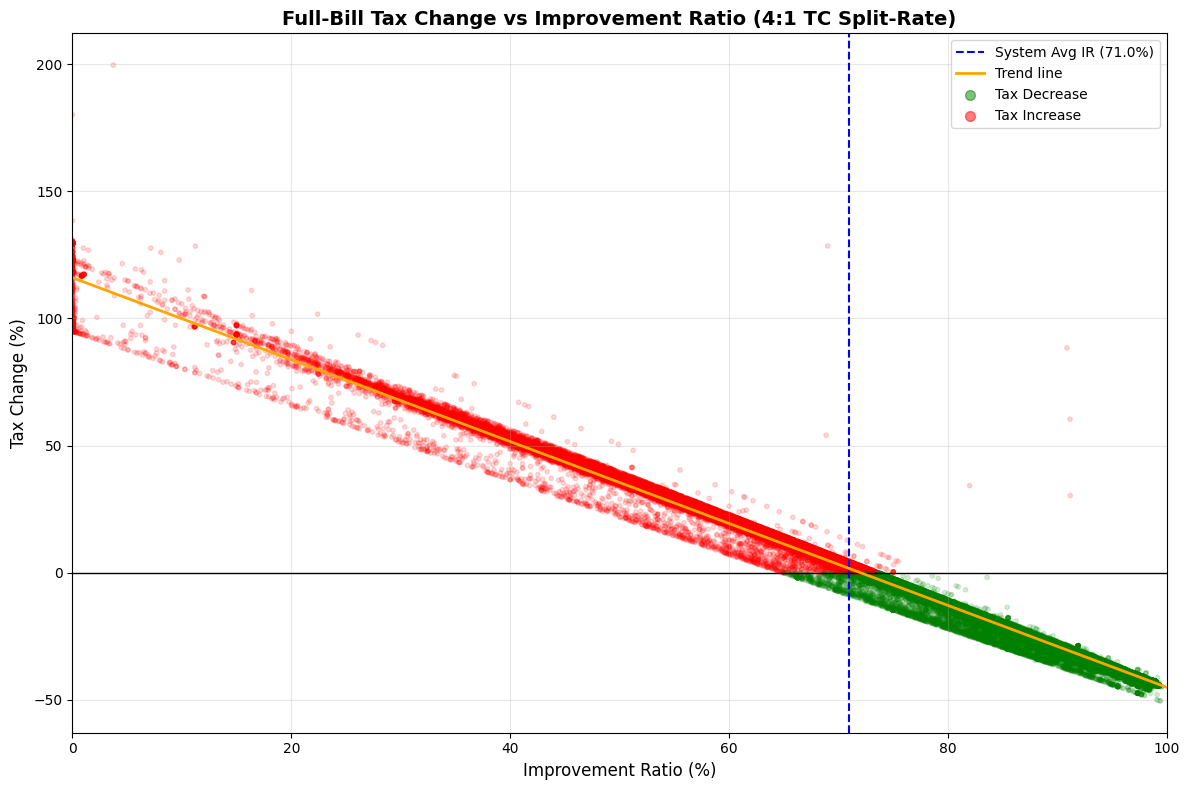


Plot shows 121,755 parcels
  Green (tax decrease): 52,701
  Red (tax increase): 69,054


In [12]:
# Scatter plot: Tax Change vs Improvement Ratio (full bill)
plot_data = mpls[(mpls['current_tax'] > 100) & (mpls['IR'].notna())
                 & (mpls['tax_change_pct_tc'].between(-100, 200))].copy()
fig, ax = plt.subplots(figsize=(12, 8))
colors = np.where(plot_data['tax_change_pct_tc'] < 0, 'green', 'red')
ax.scatter(plot_data['IR'] * 100, plot_data['tax_change_pct_tc'], alpha=0.15, s=10, c=colors)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
system_avg_ir = (mpls['bldg_mv'].sum() / mpls['emv_total'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5, label=f'System Avg IR ({system_avg_ir:.1f}%)')
z = np.polyfit(plot_data['IR'] * 100, plot_data['tax_change_pct_tc'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, p(x_line), 'orange', linewidth=2, label='Trend line')
ax.scatter([], [], c='green', alpha=0.5, s=50, label='Tax Decrease')
ax.scatter([], [], c='red', alpha=0.5, s=50, label='Tax Increase')
ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Full-Bill Tax Change vs Improvement Ratio ({tc_land_improvement_ratio}:1 TC Split-Rate)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()
print(f'\nPlot shows {len(plot_data):,} parcels')
print(f'  Green (tax decrease): {(plot_data["tax_change_pct_tc"] < 0).sum():,}')
print(f'  Red (tax increase): {(plot_data["tax_change_pct_tc"] >= 0).sum():,}')

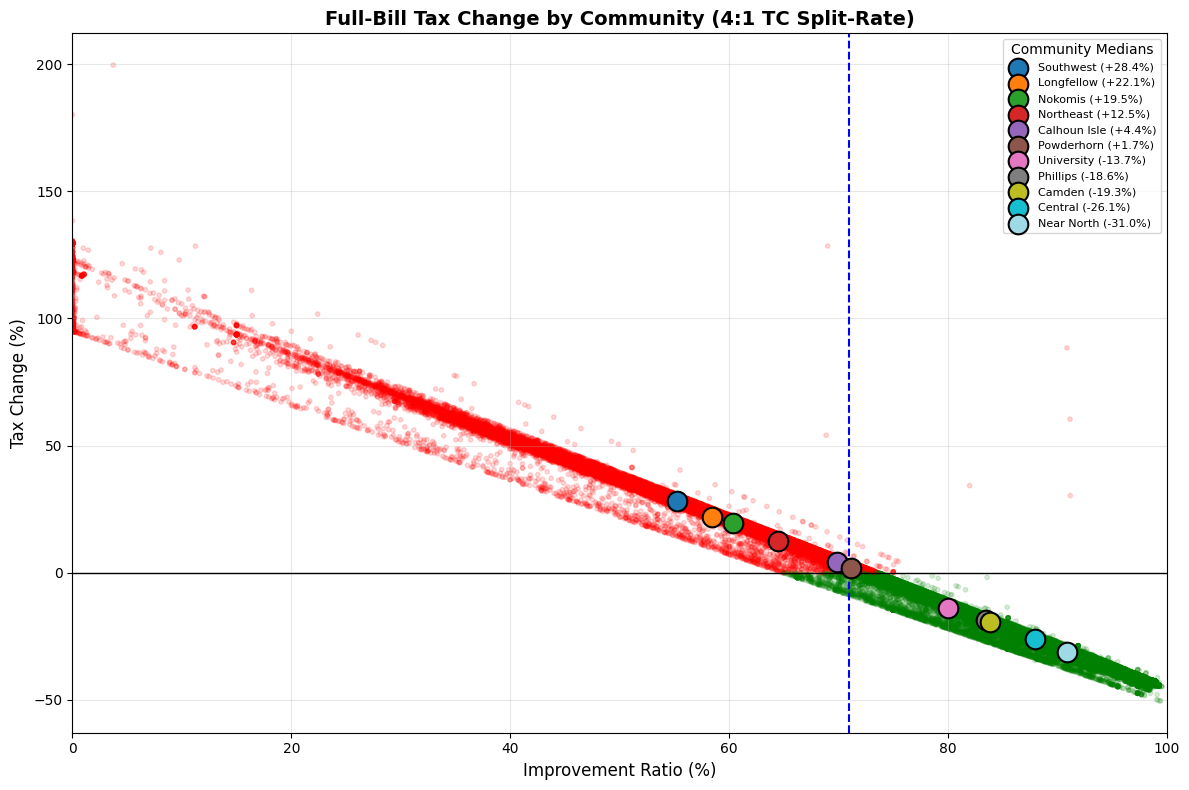


Plot shows 121,755 parcels across 11 communities


In [13]:
# Scatter plot: Tax Change by Community (full bill)
# Minneapolis Communities (11) are the analog to St. Paul's District Councils.
COMM_PATH = DATA_DIR / 'communities.gpq'
NBHD_PATH = DATA_DIR / 'neighborhoods.gpq'

def _fetch_layer(item_url, layer, name_field, cache_path):
    if cache_path.exists():
        return gpd.read_parquet(cache_path)
    q = f"{item_url}/{layer}/query"
    d = requests.get(q, params={'where': '1=1', 'outFields': name_field,
                                'returnGeometry': 'true', 'outSR': 3857, 'f': 'geojson'}).json()
    g = gpd.GeoDataFrame.from_features(d['features'], crs='EPSG:3857')
    g.to_parquet(cache_path)
    return g

communities = _fetch_layer(
    'https://services.arcgis.com/afSMGVsC7QlRK1kZ/arcgis/rest/services/Minneapolis_Communities/FeatureServer',
    0, 'CommName', COMM_PATH)[['CommName', 'geometry']].rename(columns={'CommName': 'Community'})
neighborhoods = _fetch_layer(
    'https://services.arcgis.com/afSMGVsC7QlRK1kZ/arcgis/rest/services/Minneapolis_Neighborhoods/FeatureServer',
    0, 'BDNAME', NBHD_PATH)[['BDNAME', 'geometry']].rename(columns={'BDNAME': 'Neighborhood'})

# Centroid spatial join parcels -> community + neighborhood
_pts = mpls.to_crs(epsg=3857).copy()
_pts['centroid'] = _pts.geometry.centroid
centroids = gpd.GeoDataFrame(_pts.drop(columns='geometry'), geometry='centroid', crs='EPSG:3857')
plot_with_nbhd = gpd.sjoin(centroids, communities, how='left', predicate='within').drop(columns=['index_right'])
plot_with_nbhd = gpd.sjoin(plot_with_nbhd, neighborhoods, how='left', predicate='within').drop(columns=['index_right'])
plot_with_nbhd = plot_with_nbhd.drop(columns=['centroid'])
if plot_with_nbhd.index.duplicated().any():
    plot_with_nbhd = plot_with_nbhd[~plot_with_nbhd.index.duplicated(keep='first')]

plot_data = plot_with_nbhd[(plot_with_nbhd['current_tax'] > 100)
                           & (plot_with_nbhd['Community'].notna())
                           & (plot_with_nbhd['tax_change_pct_tc'].between(-100, 200))].copy()

fig, ax = plt.subplots(figsize=(12, 8))
colors = np.where(plot_data['tax_change_pct_tc'] < 0, 'green', 'red')
ax.scatter(plot_data['IR'] * 100, plot_data['tax_change_pct_tc'], alpha=0.15, s=10, c=colors)
community_stats = plot_data.groupby('Community').agg(
    median_IR=('IR', 'median'), median_tax_change=('tax_change_pct_tc', 'median'),
    count=('net_tc', 'count')).reset_index().sort_values('median_tax_change', ascending=False)
cmap_colors = plt.cm.tab20(np.linspace(0, 1, len(community_stats)))
for i, row in enumerate(community_stats.itertuples()):
    ax.scatter(row.median_IR * 100, row.median_tax_change, s=200, c=[cmap_colors[i]],
               edgecolors='black', linewidths=1.5,
               label=f'{row.Community} ({row.median_tax_change:+.1f}%)', zorder=5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
system_avg_ir = (mpls['bldg_mv'].sum() / mpls['emv_total'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5)
ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Full-Bill Tax Change by Community ({tc_land_improvement_ratio}:1 TC Split-Rate)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, title='Community Medians')
ax.grid(True, alpha=0.3); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()
print(f'\nPlot shows {len(plot_data):,} parcels across {plot_data["Community"].nunique()} communities')

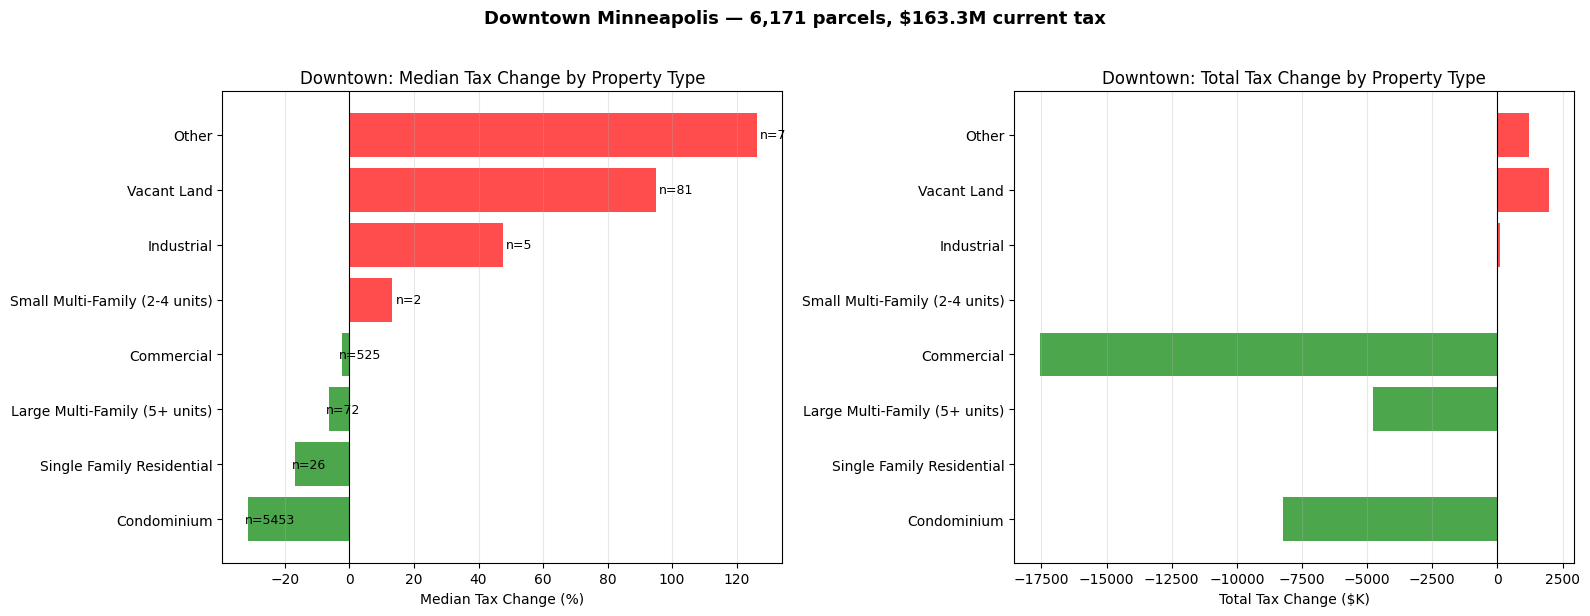


Downtown summary:
  Condominium                         n=5453  median:  -31.5%  total: $  -8,226,863
  Single Family Residential           n=  26  median:  -16.7%  total: $        +481
  Large Multi-Family (5+ units)       n=  72  median:   -6.3%  total: $  -4,760,442
  Commercial                          n= 525  median:   -2.2%  total: $ -17,571,867
  Small Multi-Family (2-4 units)      n=   2  median:  +13.3%  total: $      +3,715
  Industrial                          n=   5  median:  +47.6%  total: $    +107,228
  Vacant Land                         n=  81  median:  +95.0%  total: $  +1,965,925
  Other                               n=   7  median: +126.3%  total: $  +1,218,558


In [14]:
# Downtown tax change by property category (Downtown West + Downtown East neighborhoods)
downtown = plot_with_nbhd[plot_with_nbhd['Neighborhood'].isin(['Downtown West', 'Downtown East'])].copy()
dt_summary = downtown.groupby('PROPERTY_CATEGORY').agg(
    count=('tax_change_pct_tc', 'size'), median_change=('tax_change_pct_tc', 'median'),
    total_current=('current_tax', 'sum'), total_new=('new_tax_tc', 'sum')).reset_index()
dt_summary['total_change'] = dt_summary['total_new'] - dt_summary['total_current']
dt_summary = dt_summary.sort_values('median_change')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['green' if x < 0 else 'red' for x in dt_summary['median_change']]
bars = ax1.barh(dt_summary['PROPERTY_CATEGORY'], dt_summary['median_change'], color=colors, alpha=0.7)
for bar, count in zip(bars, dt_summary['count']):
    x = bar.get_width()
    ax1.text(x + (1 if x >= 0 else -1), bar.get_y() + bar.get_height()/2, f'n={count}', va='center', fontsize=9)
ax1.axvline(x=0, color='black', linewidth=0.8)
ax1.set_xlabel('Median Tax Change (%)'); ax1.set_title('Downtown: Median Tax Change by Property Type')
ax1.grid(True, alpha=0.3, axis='x')
colors2 = ['green' if x < 0 else 'red' for x in dt_summary['total_change']]
ax2.barh(dt_summary['PROPERTY_CATEGORY'], dt_summary['total_change'] / 1000, color=colors2, alpha=0.7)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.set_xlabel('Total Tax Change ($K)'); ax2.set_title('Downtown: Total Tax Change by Property Type')
ax2.grid(True, alpha=0.3, axis='x')
plt.suptitle(f'Downtown Minneapolis — {len(downtown):,} parcels, ${downtown["current_tax"].sum()/1e6:.1f}M current tax', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f"\nDowntown summary:")
for _, row in dt_summary.iterrows():
    print(f"  {row['PROPERTY_CATEGORY']:35s} n={row['count']:>4}  median: {row['median_change']:>+6.1f}%  total: ${row['total_change']:>+12,.0f}")

## Step 8: Census Equity Analysis

In [15]:
# Get census data for Hennepin County (cached; boundaries carry demographics + std_geoid)
import concurrent.futures
CENSUS_DATA_PATH = DATA_DIR / 'census_data.parquet'
CENSUS_BND_PATH = DATA_DIR / 'census_boundaries.gpq'

def _load_or_fetch_census():
    if CENSUS_DATA_PATH.exists() and CENSUS_BND_PATH.exists():
        print('Census: loading from cache')
        return pd.read_parquet(CENSUS_DATA_PATH), gpd.read_parquet(CENSUS_BND_PATH)
    _ex = concurrent.futures.ThreadPoolExecutor(max_workers=1)
    _fut = _ex.submit(get_census_data_with_boundaries, STATE_FIPS + COUNTY_FIPS, 2022)
    try:
        _cd, _cg = _fut.result(timeout=180); _ex.shutdown(wait=False)
    except Exception:
        _ex.shutdown(wait=False); raise
    pd.DataFrame(_cd).to_parquet(CENSUS_DATA_PATH); _cg.to_parquet(CENSUS_BND_PATH)
    print('Census: fetched and cached'); return _cd, _cg

try:
    census_data, census_boundaries = _load_or_fetch_census()
    census_boundaries = census_boundaries.set_crs(epsg=4326, allow_override=True)
    boundary_gdf = mpls.to_crs(epsg=4326)
    df = match_to_census_blockgroups(gdf=boundary_gdf, census_gdf=census_boundaries, join_type='left')
    if 'minority_pct' not in df.columns and {'total_pop', 'white_pop'} <= set(df.columns):
        df['minority_pct'] = ((df['total_pop'] - df['white_pop']) / df['total_pop'] * 100).round(2)
    if 'black_pct' not in df.columns and {'total_pop', 'black_pop'} <= set(df.columns):
        df['black_pct'] = (df['black_pop'] / df['total_pop'] * 100).round(2)
    _census_cols = ['std_geoid', 'median_income', 'minority_pct', 'black_pct',
                    'total_pop', 'white_pop', 'black_pop', 'hispanic_pop']
    for _col in _census_cols:
        if _col in df.columns:
            mpls[_col] = df[_col]
    _n = mpls['median_income'].notna().sum()
    print(f'Census block groups: {census_data.shape[0]}')
    print(f'Parcels with census data: {_n:,} of {len(mpls):,} ({_n/len(mpls)*100:.1f}%)')
except Exception as e:
    print(f'Census join skipped: {type(e).__name__}: {e}')
    for _col in ['std_geoid', 'median_income', 'minority_pct', 'black_pct',
                 'total_pop', 'white_pop', 'black_pop', 'hispanic_pop']:
        if _col not in mpls.columns:
            mpls[_col] = float('nan')
    df = mpls.copy()

Census: loading from cache


Census block groups: 1098
Parcels with census data: 119,068 of 122,736 (97.0%)


In [16]:
import seaborn as sns

def filter_data(df):
    df_filtered = df[df['median_income'] > 0].copy()
    non_vacant_df = df[(df['PROPERTY_CATEGORY'] != 'Vacant Land') & (df['median_income'] > 0)].copy()
    return df_filtered, non_vacant_df

def weighted_median(values, weights):
    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = np.array(values)[mask]; weights = np.array(weights)[mask]
    if len(values) == 0:
        return np.nan
    sorter = np.argsort(values); values = values[sorter]; weights = weights[sorter]
    cumsum = np.cumsum(weights); cutoff = weights.sum() / 2.0
    return values[np.searchsorted(cumsum, cutoff)]

def create_quintile_summary(df, group_col, value_col):
    if group_col == 'median_income':
        df = df[df['median_income'] > 0].copy()
    df[f'{group_col}_quintile'] = pd.qcut(df[group_col], 5, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])
    summary = df.groupby(f'{group_col}_quintile', observed=True).apply(
        lambda g: pd.Series({
            'count': g['tax_change_tc'].count(),
            'mean_tax_change_pct': g['tax_change_pct_tc'].mean(),
            'median_tax_change_pct': weighted_median(g['tax_change_pct_tc'].values, np.ones(len(g))),
            'mean_value': g[value_col].mean()})).reset_index()
    return summary

gdf_filtered, non_vacant_gdf = filter_data(df)
print(f'Filtered parcels: {len(gdf_filtered):,}')
print(f'Non-vacant parcels: {len(non_vacant_gdf):,}')

income_quintile_summary = create_quintile_summary(gdf_filtered, 'median_income', 'median_income')
non_vacant_income_quintile_summary = create_quintile_summary(non_vacant_gdf, 'median_income', 'median_income')
minority_quintile_summary = create_quintile_summary(gdf_filtered, 'minority_pct', 'minority_pct')
non_vacant_minority_quintile_summary = create_quintile_summary(non_vacant_gdf, 'minority_pct', 'minority_pct')

print('\nTax impact by income quintile (all properties):'); display(income_quintile_summary)
print('\nTax impact by income quintile (excluding vacant land):'); display(non_vacant_income_quintile_summary)
print('\nTax impact by minority % quintile (all properties):'); display(minority_quintile_summary)
print('\nTax impact by minority % quintile (excluding vacant land):'); display(non_vacant_minority_quintile_summary)

Filtered parcels: 119,068
Non-vacant parcels: 116,846



Tax impact by income quintile (all properties):


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_43968/275384264.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile', observed=True).apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_43968/275384264.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile', observed=True).apply(
/var/folders/cc/hk

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),23822.0,-10.405078,-20.676058,47777.492864
1,Q2,23922.0,2.552458,1.437018,73653.877978
2,Q3,23749.0,7.051922,9.308196,93310.613921
3,Q4,23978.0,12.180074,15.169007,114050.362457
4,Q5 (Highest),23597.0,16.125662,20.181962,172309.223800



Tax impact by income quintile (excluding vacant land):


,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),23376.0,-15.508930,-21.500649,48377.938912
1,Q2,23402.0,0.893104,1.633350,74120.272370
2,Q3,23770.0,5.759506,9.103867,93889.035255
3,Q4,23252.0,11.029879,14.902776,114743.334767
4,Q5 (Highest),23046.0,15.264687,19.941044,173058.292459



Tax impact by minority % quintile (all properties):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),23848.0,18.312816,19.949657,7.687061
1,Q2,24039.0,14.722226,17.847173,16.023526
2,Q3,23736.0,2.401569,5.040833,24.980963
3,Q4,23772.0,4.263860,3.437598,38.590361
4,Q5 (Highest),23673.0,-12.493494,-21.307777,71.346346



Tax impact by minority % quintile (excluding vacant land):


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),23510.0,17.864567,19.967537,7.648558
1,Q2,23471.0,13.126490,17.052110,15.891814
2,Q3,23365.0,1.634920,4.454651,24.751464
3,Q4,23386.0,1.750905,3.172387,38.142400
4,Q5 (Highest),23114.0,-17.466060,-22.036469,70.985238


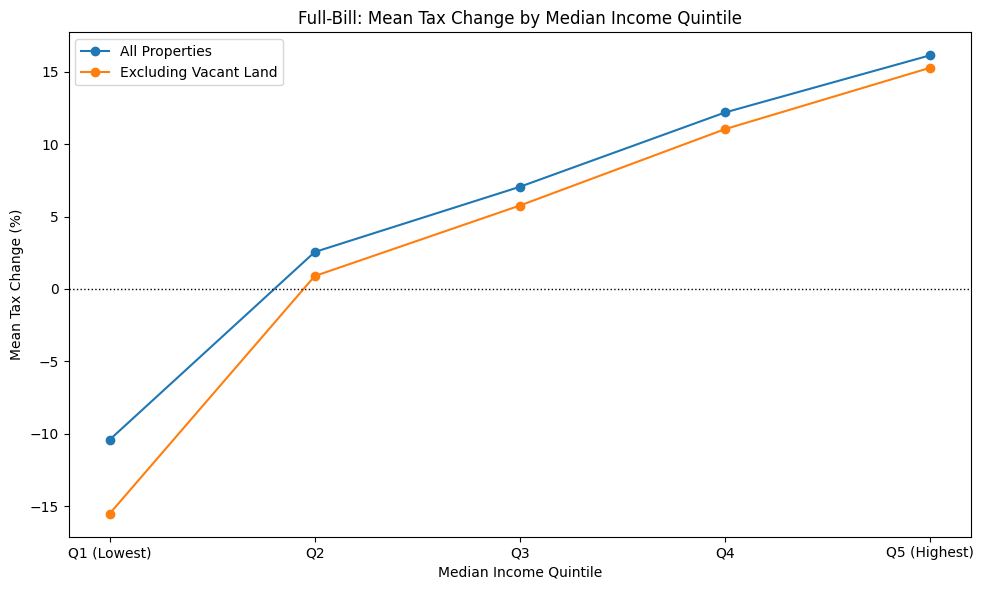

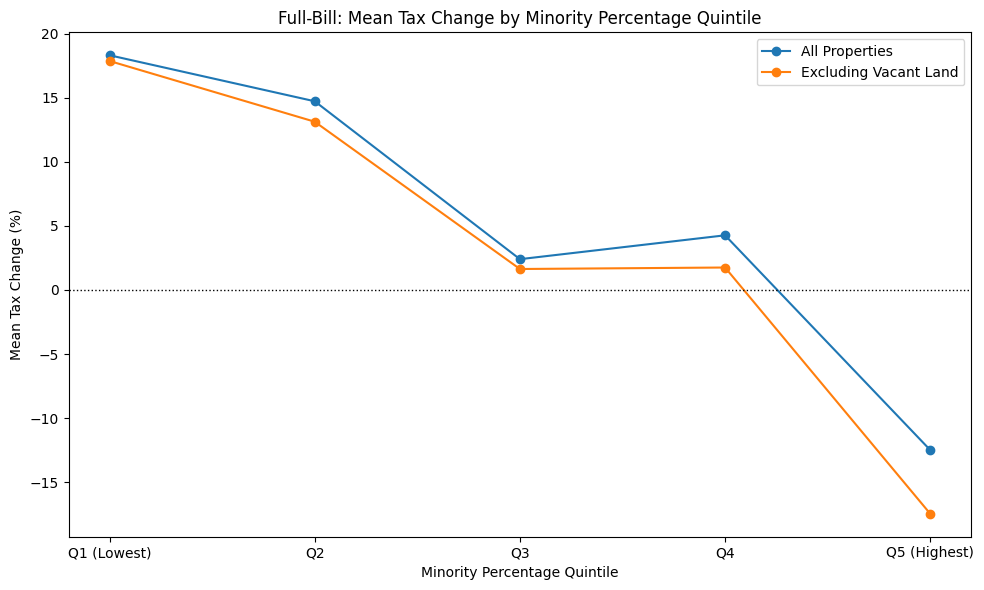

In [17]:
# Quintile line plots
plt.figure(figsize=(10, 6))
plt.plot(income_quintile_summary['median_income_quintile'], income_quintile_summary['mean_tax_change_pct'], marker='o', label='All Properties')
plt.plot(non_vacant_income_quintile_summary['median_income_quintile'], non_vacant_income_quintile_summary['mean_tax_change_pct'], marker='o', label='Excluding Vacant Land')
plt.xlabel('Median Income Quintile'); plt.ylabel('Mean Tax Change (%)')
plt.title('Full-Bill: Mean Tax Change by Median Income Quintile')
plt.legend(); plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 6))
plt.plot(minority_quintile_summary['minority_pct_quintile'], minority_quintile_summary['mean_tax_change_pct'], marker='o', label='All Properties')
plt.plot(non_vacant_minority_quintile_summary['minority_pct_quintile'], non_vacant_minority_quintile_summary['mean_tax_change_pct'], marker='o', label='Excluding Vacant Land')
plt.xlabel('Minority Percentage Quintile'); plt.ylabel('Mean Tax Change (%)')
plt.title('Full-Bill: Mean Tax Change by Minority Percentage Quintile')
plt.legend(); plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout(); plt.show()

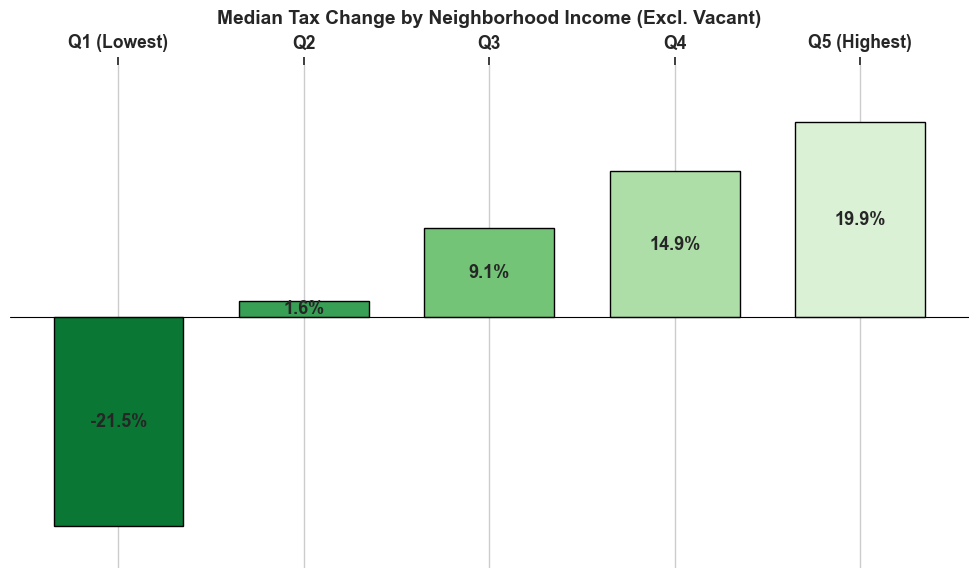

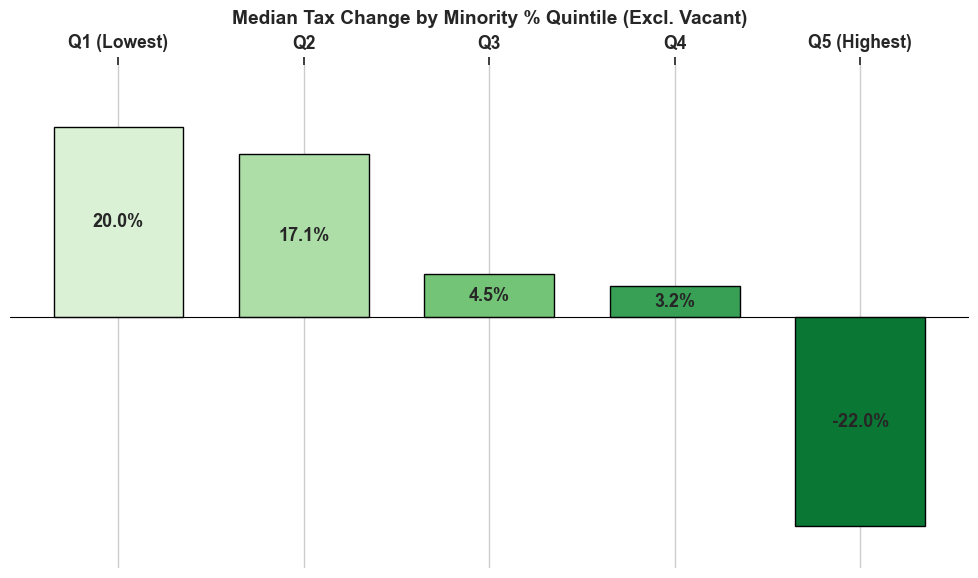

In [18]:
# Inverted bar charts: median tax change by quintile (excluding vacant land)
sns.set_theme(style='whitegrid', font_scale=1.15)

def _inverted_bar(vals, labels, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette('Greens', n_colors=len(vals))
    color_map = [colors[i] for i in np.argsort(np.argsort(-vals.values))]
    bars = ax.bar(labels, vals, color=color_map, edgecolor='black', width=0.7)
    ax.yaxis.set_visible(False)
    ax.set_title(title, weight='bold', pad=30)
    sns.despine(left=True, right=True, top=True, bottom=True)
    for bar, val in zip(bars, vals):
        ax.annotate(f'{val:.1f}%', xy=(bar.get_x() + bar.get_width()/2, val/2), ha='center', va='center', fontsize=13, fontweight='bold')
    ax.xaxis.set_ticks_position('top'); ax.xaxis.set_label_position('top')
    plt.xticks(fontweight='bold')
    margin = max(abs(vals.min()), abs(vals.max())) * 1.2
    ax.set_ylim(-margin, margin); ax.axhline(y=0, color='black', linewidth=0.8)
    plt.tight_layout(); plt.show()

_inverted_bar(non_vacant_income_quintile_summary['median_tax_change_pct'],
              non_vacant_income_quintile_summary['median_income_quintile'],
              'Median Tax Change by Neighborhood Income (Excl. Vacant)')
_inverted_bar(non_vacant_minority_quintile_summary['median_tax_change_pct'],
              non_vacant_minority_quintile_summary['minority_pct_quintile'],
              'Median Tax Change by Minority % Quintile (Excl. Vacant)')

Single family parcels: 72,912


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_43968/275384264.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile', observed=True).apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_43968/275384264.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile', observed=True).apply(


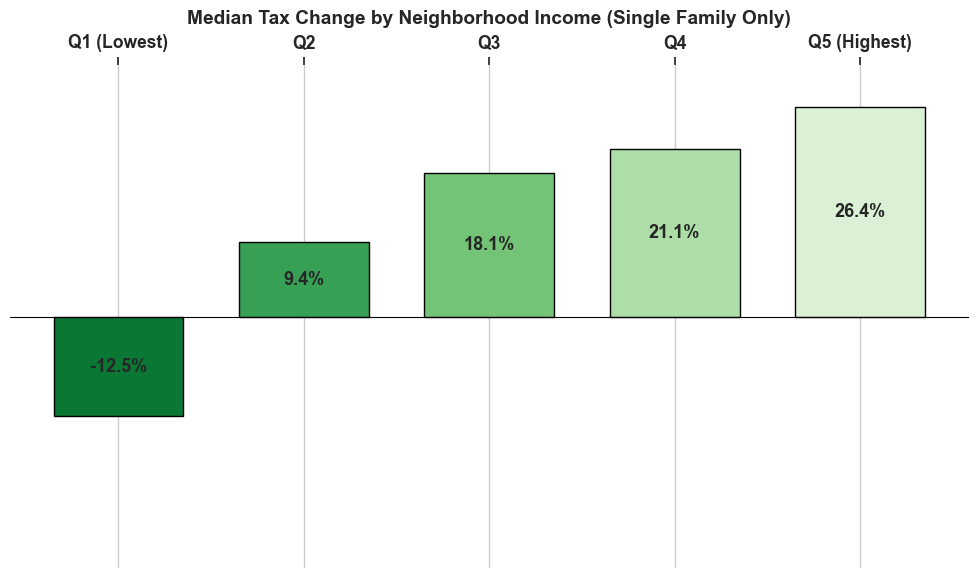

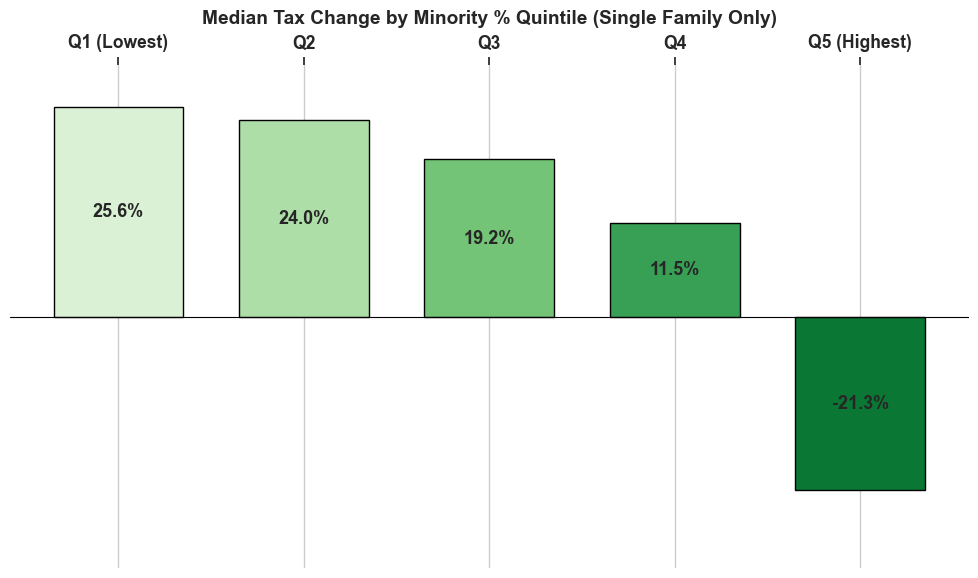

In [19]:
# Inverted bar charts: single family residential only
sfr = df[(df['PROPERTY_CATEGORY'] == 'Single Family Residential') & (df['median_income'] > 0)].copy()
print(f'Single family parcels: {len(sfr):,}')
sfr_income_quintile = create_quintile_summary(sfr, 'median_income', 'median_income')
sfr_minority_quintile = create_quintile_summary(sfr, 'minority_pct', 'minority_pct')
_inverted_bar(sfr_income_quintile['median_tax_change_pct'], sfr_income_quintile['median_income_quintile'],
              'Median Tax Change by Neighborhood Income (Single Family Only)')
_inverted_bar(sfr_minority_quintile['median_tax_change_pct'], sfr_minority_quintile['minority_pct_quintile'],
              'Median Tax Change by Minority % Quintile (Single Family Only)')

Multifamily parcels: 16,123


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_43968/275384264.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile', observed=True).apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_43968/275384264.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile', observed=True).apply(


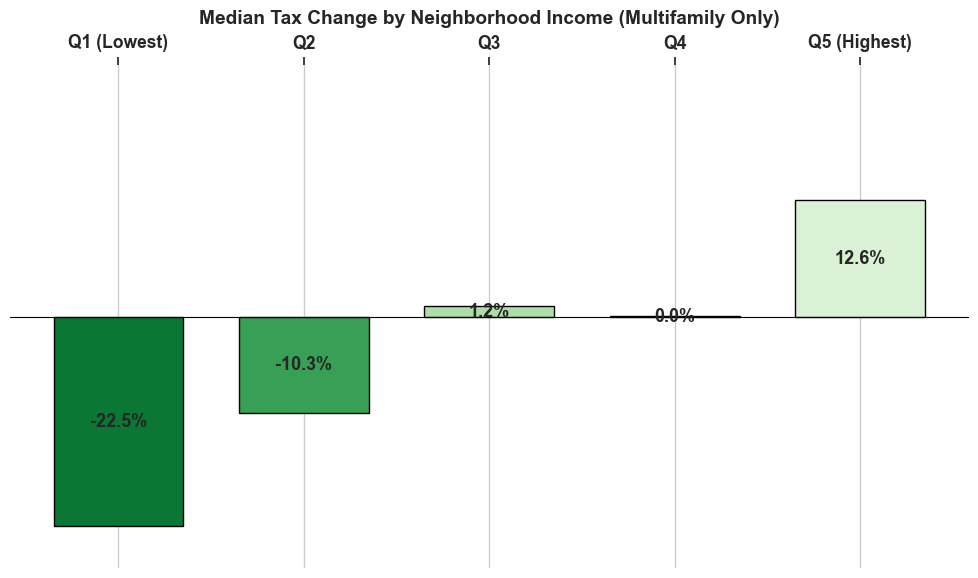

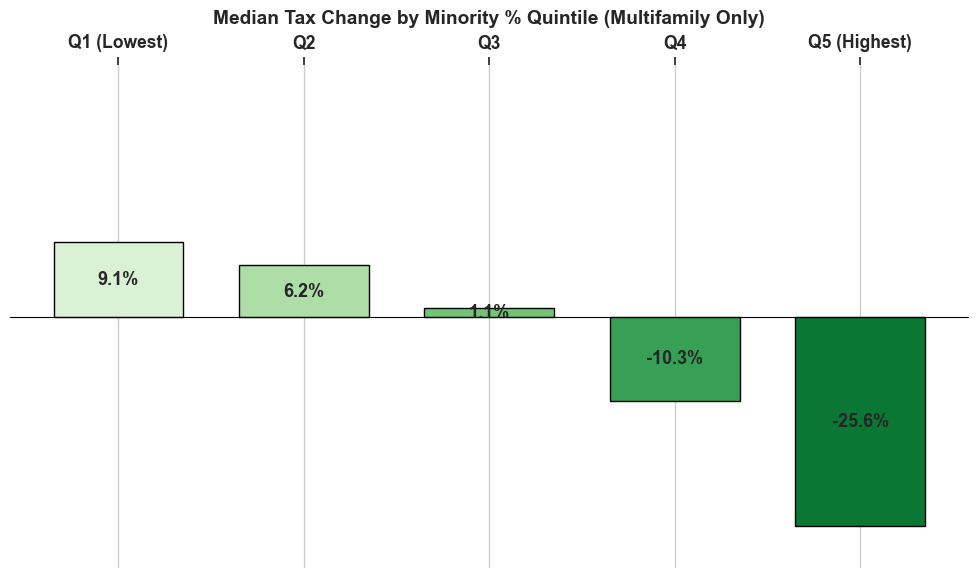

In [20]:
# Inverted bar charts: multifamily residential only
mfr = df[(df['PROPERTY_CATEGORY'].isin(['Small Multi-Family (2-4 units)', 'Large Multi-Family (5+ units)'])) & (df['median_income'] > 0)].copy()
print(f'Multifamily parcels: {len(mfr):,}')
mfr_income_quintile = create_quintile_summary(mfr, 'median_income', 'median_income')
mfr_minority_quintile = create_quintile_summary(mfr, 'minority_pct', 'minority_pct')
_inverted_bar(mfr_income_quintile['median_tax_change_pct'], mfr_income_quintile['median_income_quintile'],
              'Median Tax Change by Neighborhood Income (Multifamily Only)')
_inverted_bar(mfr_minority_quintile['median_tax_change_pct'], mfr_minority_quintile['minority_pct_quintile'],
              'Median Tax Change by Minority % Quintile (Multifamily Only)')

Residential parcels: 89,035


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_43968/275384264.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile', observed=True).apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_43968/275384264.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile', observed=True).apply(


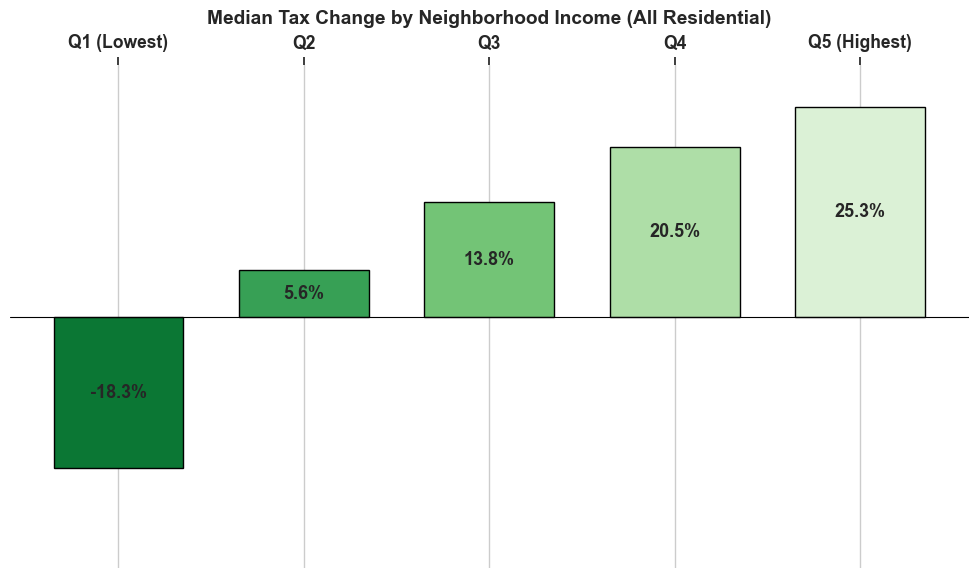

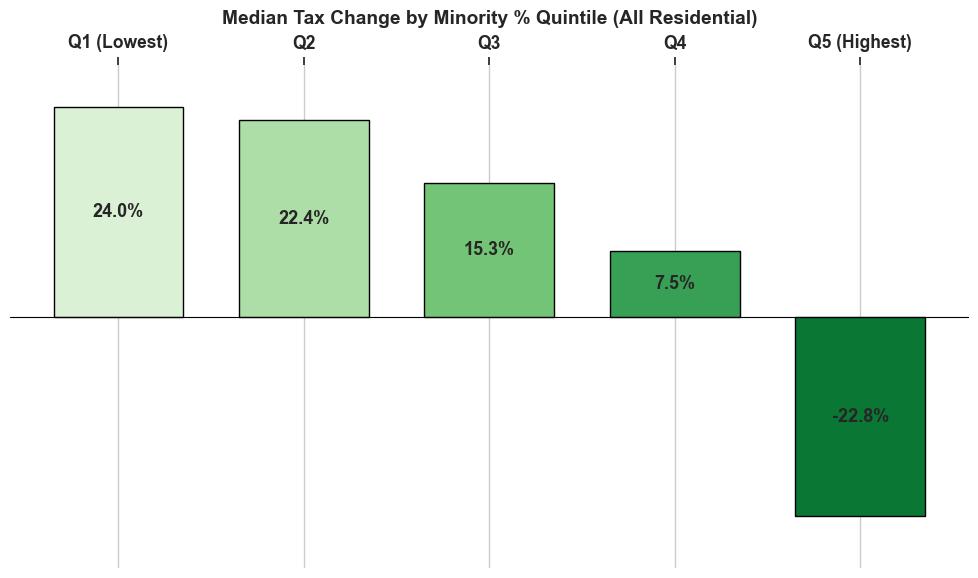

In [21]:
# Inverted bar charts: all residential (SFR + multifamily)
smfr = df[(df['PROPERTY_CATEGORY'].isin(['Single Family Residential', 'Small Multi-Family (2-4 units)', 'Large Multi-Family (5+ units)'])) & (df['median_income'] > 0)].copy()
print(f'Residential parcels: {len(smfr):,}')
smfr_income_quintile = create_quintile_summary(smfr, 'median_income', 'median_income')
smfr_minority_quintile = create_quintile_summary(smfr, 'minority_pct', 'minority_pct')
_inverted_bar(smfr_income_quintile['median_tax_change_pct'], smfr_income_quintile['median_income_quintile'],
              'Median Tax Change by Neighborhood Income (All Residential)')
_inverted_bar(smfr_minority_quintile['median_tax_change_pct'], smfr_minority_quintile['minority_pct_quintile'],
              'Median Tax Change by Minority % Quintile (All Residential)')

In [22]:
# Save modeled data for downstream use
mpls.to_parquet(os.path.join('data', 'minneapolis_city_modeled.gpq'))
minneapolis_gdf.to_parquet(os.path.join('data', 'minneapolis_gdf.gpq'))
print(f'Saved {len(mpls):,} city-taxable parcels and {len(minneapolis_gdf):,} total parcels')

Saved 122,736 city-taxable parcels and 128,750 total parcels


In [23]:
# Export standardized CSV — do not remove or move above Census join
# taxable land/improvement value basis (market values)
mpls['taxable_land_value'] = mpls['land_mv'].clip(lower=0)
mpls['taxable_improvement_value'] = mpls['bldg_mv'].clip(lower=0)

out_df = save_standard_export(
    df=mpls,
    city='minneapolis',
    output_path='../../analysis/data/minneapolis.csv',
    model_type=MODEL_TYPE,
    land_millage=tc_land_millage,
    improvement_millage=tc_imp_millage,
    property_category_col='PROPERTY_CATEGORY',
    current_tax_col='current_tax',
    new_tax_col='new_tax_tc',
    tax_change_col='tax_change_tc',
    tax_change_pct_col='tax_change_pct_tc',
    taxable_land_col='taxable_land_value',
    taxable_improvement_col='taxable_improvement_value',
)

  ✓ minneapolis: 122,736 rows → ../../analysis/data/minneapolis.csv  [model: split_rate:4.0]


In [24]:
# Standard report: category impact, income quintile, distribution
from lvt.viz import create_city_report
create_city_report(out_df, 'minneapolis', show=False)
print('Done.')

Done.
